# ノイズ除去で、異常検知は良くなるか？ — 第2回の実験を読む

[Zenn第1回](https://zenn.dev/kasahart/articles/kasahart-20260919-dcase2026-asd-01)・[第2回草稿](https://github.com/kasahart/zenn/pull/9)の続きです。記事では、**同じ検知器に渡す音だけを変えたとき、成績がどう変わるか**を比較しました。このNotebookでは結果の表を読み、合成音の図で2種類の引き算の違いを確かめます。

**GitHubで読むだけなら、実行やインストールは不要です。** 保存済みの表と5枚の図を、そのまま下へ読んでください。音声・重みのダウンロードも不要です。試聴や自分での実行は後半の「4. 自分で実行する」から始めます。GitHub上では試聴ボタンを使いません。

## 1. 4条件で何を変えたか

| 記号 | 記事での呼び方 | 検知器に渡す音 |
|---|---|---|
| B0 | 近いマイクのみ | 近いマイクの録音をそのまま使う。比較の基準 |
| B1 | 遠いマイクのみ | 遠いマイクの録音をそのまま使う |
| W1 | 線形減算（複素減算） | 遠い側の大きさと位相を調整して、近い側から引く |
| SS | スペクトル減算（式1） | 周波数ごとの大きさを引き、近い側の位相で波形へ戻す |

どの条件もBEATs・RDP・BEAM・VarMinの設定は共通です。**正常音の比較基準も、それぞれの条件で作り直します。** B0の正常音の特徴に、処理後のW1やSSをそのまま比べる実験ではありません。

*次のセルは表示の準備コードです。読むだけなら飛ばして、結果の表へ進んでください。*

In [1]:
%matplotlib inline
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import wandas as wd
from IPython.display import display
from asd_min.notebook import frames, show
from asd_min.runner import run, plan
from asd_min.evaluation import evaluate
ROOT = Path.cwd() if (Path.cwd()/"results").is_dir() else Path.cwd().parent
assert (ROOT/"results/summary-with-ss.csv").is_file()
assert wd.__version__ == "0.8.0"
ENABLE_AUDIO = False  # Trueで手動再生controlを生成。自動再生しない。
plt.rcParams.update({"font.size": 11, "figure.dpi": 100})

## 2. 結果の読み方 — W1は上がり、SSは総合では上がらなかった

次の表の「総合スコア」は記事の検証スコアと同じものです。高いほど良く、「B0との差」は近いマイクのみを基準にした**ポイント差**です。スコア66.835は「故障の66.835%を検出した」という意味ではありません。

In [2]:
summary = pd.read_csv(ROOT/"results/summary-with-ss.csv").set_index("condition").reindex(["b0","b1","w1","ss"])
CONDITION_NAMES = {"b0":"B0：近いマイク", "b1":"B1：遠いマイク", "w1":"W1：線形減算", "ss":"SS：スペクトル減算"}
totals = summary["official_score"]*100
reading_table = pd.DataFrame({"条件":[CONDITION_NAMES[c] for c in summary.index],
                              "総合スコア":totals.to_numpy(),
                              "B0との差（ポイント）":(totals-totals.loc["b0"]).to_numpy()})
display(reading_table.round(3))

,条件,総合スコア,B0との差（ポイント）
0,B0：近いマイク,62.841,0.000
1,B1：遠いマイク,58.362,-4.479
2,W1：線形減算,66.835,3.994
3,SS：スペクトル減算,62.325,-0.516


**この比較では、W1はB0より3.994ポイント高く、SSは0.516ポイント低い結果です。** 遠いマイクを使えば必ず改善するわけではなく、使い方で結果が変わりました。SS一般が無効だと結論づける結果ではありません。

### 機種ごとの結果も見る

pAUCは、正常音への誤警報を少なく抑えた範囲で、異常を見分ける成績です。表と棒グラフはpAUCを100倍し、0〜100で示しています。グラフの機種名は配布データの英語名です。日本語との対応は表に示します。

condition,B0：近いマイク,B1：遠いマイク,W1：線形減算,SS：スペクトル減算
machine,,,,
集じん機（BlowerDustCollector）,72.000,59.842,73.158,73.474
研磨機（Sander）,51.947,49.263,55.947,52.368
ミシン（SewingMachine）,66.000,59.158,67.105,64.684
電動歯ブラシ（ToothBrush）,50.158,51.368,53.211,49.632
小型ドローン（ToyDrone）,57.842,57.105,62.316,57.579


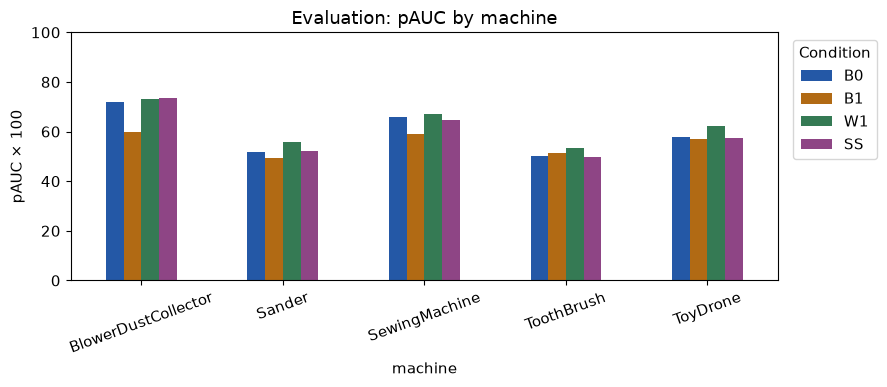

In [3]:
by_machine = pd.read_csv(ROOT/"results/by_machine-with-ss.csv")
pauc = by_machine.pivot(index="machine", columns="condition", values="pauc").reindex(columns=["b0","b1","w1","ss"])*100
MACHINE_NAMES = {"BlowerDustCollector":"集じん機（BlowerDustCollector）", "Sander":"研磨機（Sander）",
                 "SewingMachine":"ミシン（SewingMachine）", "ToothBrush":"電動歯ブラシ（ToothBrush）", "ToyDrone":"小型ドローン（ToyDrone）"}
display(pauc.rename(index=MACHINE_NAMES, columns=CONDITION_NAMES).round(3))
ax=pauc.rename(columns={c:c.upper() for c in pauc.columns}).plot.bar(figsize=(9,4), rot=20,
    color=["#2458a6","#b16a14","#357a54","#8e4585"])
ax.set(title="Evaluation: pAUC by machine", ylabel="pAUC × 100", ylim=(0,100))
ax.legend(title="Condition", loc="upper left", bbox_to_anchor=(1.01,1))
plt.tight_layout(); plt.show()

**見る点：** 各機種のB0（青）とW1（緑）、SS（紫）を比べます。W1は5機種とも上がりました。SSは集じん機・研磨機で上がり、残る3機種では下がっています。総合値だけでなく、機種ごとの差も見る必要があります。

## 3. 合成図で、引き算の違いを見る

ここからは**実際の機械の録音ではなく、仕組みを説明するための1秒の合成音**です。両マイクに1 kHzの共通音を入れ、近い側にだけ1.9 kHzの音を加えています。共通音は近い側で大きさ0.8、遠い側で0.4とし、位相もずらしています。近い側だけの音は大きさ0.12です。

左の図は冒頭40 msの波形です。縦軸の振幅を全条件で−1〜1にそろえています。右の図は1秒全体を「時間×周波数」で見たものです。横軸が時間、縦軸が周波数、色は成分の強さ（dB）です。赤・黄ほど強く、青ほど弱く見えます。**1,000 Hzと1,900 Hzの横線**に注目してください。色の範囲も全条件で−100〜0 dBにそろえています。

このデモでは、共通音を弱めて近い側だけの音を残す様子を見ます。ただし実録音では、共通音にも残したい機械音が含まれます。合成音での減衰を、検知成績や聞きやすさの改善の証拠にはしません。

In [4]:
demo = frames()  # CLIと同じcondition_audio()で計算し、Wandasで表示する

def display_demo(condition):
    frame = demo[condition]
    fig = show(frame, audio=False)
    # 表示だけを調整。強い成分が同じ色に飽和しない共通範囲（-100〜0 dB）。
    fig.axes[1].collections[0].set_clim(-100, 0)
    display(fig); plt.close(fig)
    if ENABLE_AUDIO:
        show(frame, audio=True)

### B0：近いマイク — 引く前の基準

**見る点：** 1,000 Hzの強い横線と、1,900 Hzの弱い横線が見えます。ここには共通音と近い側だけの音が両方入っています。まずこの2本の位置を覚えて、後の図と比べてください。

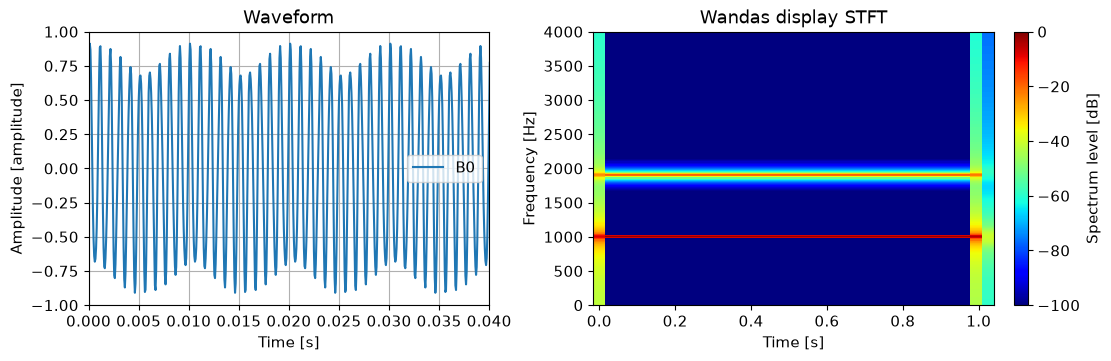

In [5]:
display_demo("b0")

### B1：遠いマイク — 引き算の手掛かり

**見る点：** 1,000 Hzの共通音がありますが、この合成設定では1,900 Hzの音を入れていません。B0より波形の振幅も小さくなります。実録音の遠いマイクに機械音が入らないという意味ではありません。

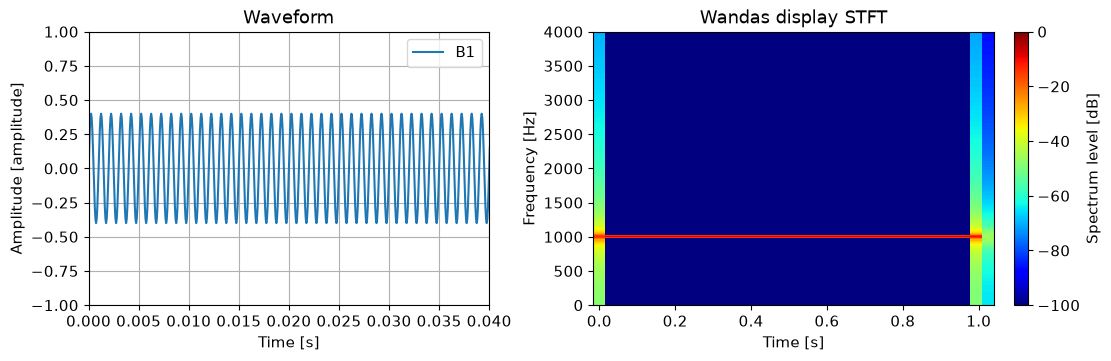

In [6]:
display_demo("b1")

### W1：大きさと位相を合わせて引く

**見る点：** 録音の中央では1,000 Hzの線が大きく弱まり、1,900 Hzの線は残ります。遠い側の大きさと位相を合わせてから共通成分を引くためです。端では成分が残っており、完全にゼロになるとは言いません。

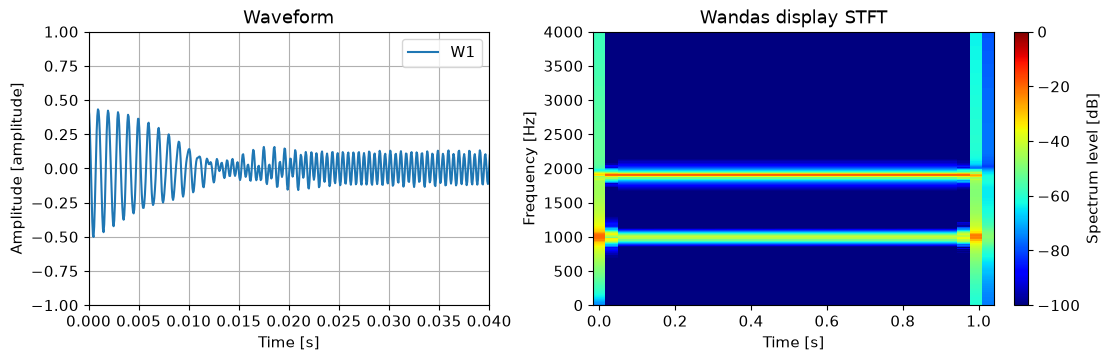

In [7]:
display_demo("w1")

### SS：大きさだけを引く

**見る点：** 1,000 Hzの線はB0より弱まりますが、W1より強く残ります。このデモでは近い側0.8から遠い側0.4を引くためです。遠い側にない1,900 Hzの線は残ります。式1は近い側の大きさが遠い側以下なら近い側の0.1倍を残し、近い側の位相で復元します。

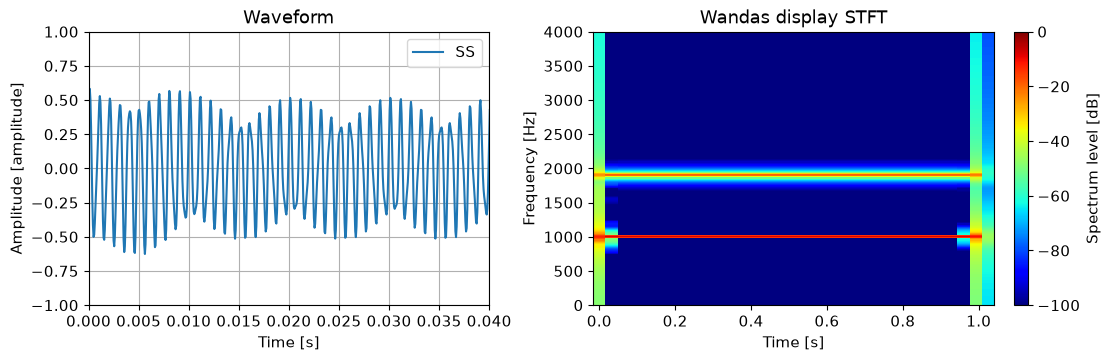

In [8]:
display_demo("ss")

### 図から言えることと、実測との違い

W1とSSは、同じ遠いマイクを使っても引き方が違います。この合成例ではW1のほうが共通音を強く抑えました。しかし**共通音を強く減らすことと、異常を見分けやすくすることは別の評価**です。記事のスコアは実データで測った値、上の図は処理を理解するためのデモです。

図の音声はCLI共通のTorch関数で計算し、Wandas 0.8.0で可視化しています。表示用STFTは全条件1,024/hop512にそろえています。実験用SSは512/hop256であり、表示用STFTとは異なります。W1は録音の端を含めて係数を推定します。記事の別の合成図で端各2フレームを除く処理を、実験へ転用していません。

### ここまでのまとめ

記事の比較では、W1がこの5機種で改善し、SSは総合では改善しませんでした。図は2種類の引き方を示す合成デモです。未知設備への汎化や聞きやすさは別に確かめる必要があります。

**読むだけなら、ここまでで終わりです。** 手を動かしたい方は次の4章へ、指標や条件を詳しく確認したい方は末尾の5章へ進んでください。

## 4. 自分で実行する（ここから任意）

読むだけならここまでで結果と図を確認できます。実行する場合はリポジトリを取得し、[READMEの環境準備](../README.md#自分で実行する)を済ませ、Pythonのkernelを選んでから上の準備セルへ戻ります。Notebookを上から実行しても、既定では保存表と合成デモだけです。

| やりたいこと | 変更するもの | 追加で必要なもの |
|---|---|---|
| 保存表と合成図を作り直す | 既定のまま上から実行 | READMEのPython環境だけ |
| 合成音を手動で聞く | 準備セルの`ENABLE_AUDIO=True`、合成デモを再実行 | データ・重みは不要 |
| 自分で取得した録音を眺める | 次の`AUDIO_PATH` | 公式の16 kHz・2ch音声 |
| 保存異常度を公式再採点 | `EVALUATOR`と`TERMS_REVIEWED` | 自分で取得した評価器・正解と用途条件確認 |
| 生音声から新しい異常度を計算 | `DATA_ROOT`・`CHECKPOINT`・`RUN_INFERENCE` | 公式音声と固定BEATs_iter3 |

試聴はNotebook実行環境で生成される再生ボタンを手動で押します。自動再生はしません。`describe(normalize=False)`で比較の音量関係を保ちますが、音の主観的な聞きやすさは未検証です。配布Notebookに音声出力を埋め込まないため、既定は`ENABLE_AUDIO=False`です。

### 4.1 読者の生音声を眺める（特徴推論はしない）

[公式入力の取得](../docs/inputs.md)を確認し、`AUDIO_PATH`へファイルのpathを指定します。2chはch0が近いマイク、ch1が遠いマイクです。結果はメモリ上だけで扱います。データや音声出力を公開Notebookへ保存しないでください。

In [9]:
AUDIO_PATH = None  # Path("/path/to/eval_data/raw/ToothBrush/test/section_00_0000.wav")
if AUDIO_PATH is not None:
    for condition, frame in frames(path=AUDIO_PATH).items():
        print(condition.upper())
        fig=show(frame); display(fig); plt.close(fig)
        if ENABLE_AUDIO: show(frame,audio=True)
else:
    print("Optional real-audio inspection skipped")

Optional real-audio inspection skipped


### 4.2 保存異常度を再採点（音声の特徴は計算し直さない）

ここで行うのは、保存CSVの「正常音からの外れ具合」と正解を照合して指標を計算する処理です。[評価器の利用条件](../docs/rights.md)を自分の用途に照らして確認してください。評価器と正解は同梱しません。読者取得の固定コミット・無改変clean checkoutを指定します。

`TERMS_REVIEWED=True`は許諾取得や契約同意を代行する機能ではありません。必要な資産と条件がそろうまで既定のままにします。

In [10]:
EVALUATOR = None  # Path("/path/to/official-evaluator")
TERMS_REVIEWED = False
RESCORE_OUTPUT = ROOT/"outputs/rescore-notebook"
if EVALUATOR is not None and TERMS_REVIEWED:
    for condition in ("b0","b1","w1","ss"):
        print(evaluate(ROOT/"results"/condition, EVALUATOR, RESCORE_OUTPUT/condition, terms_reviewed=True))
else:
    print("Official rescoring skipped: external assets and terms required")

Official rescoring skipped: external assets and terms required


### 4.3 生音声から再推論（正常参照も作り直す）

[取得先とchecksum](../docs/inputs.md)を確認し、音声rootとBEATs_iter3のpathを指定します。CLIと同じ`run()`で4条件それぞれの正常参照と異常度を計算します。

既定はCPU・電動歯ブラシのtrain5/test5件です。これは動作確認用で、少数の正常参照を使うため記事スコアにはなりません。全件は`MACHINES=None; LIMIT=None`へ変更します。先に小規模実行で自分の機器の時間・メモリを確認してください。出力先は上書きしないため、再実行時は`OUTPUT`を新しいディレクトリへ変えます。

新しく計算した異常度を公式採点する場合は、4.2の`evaluate()`へ、この`OUTPUT`配下の条件ディレクトリを指定します。全5機種の完全な出力が必要で、小規模確認の結果は公式全体スコアとして採点できません。

In [11]:
DATA_ROOT = None  # Path("/path/to/eval_data/raw")
CHECKPOINT = None  # Path("/path/to/BEATs_iter3.pt")
RUN_INFERENCE = False  # 読者の取得資産・条件・資源を確認して変更
MACHINES = ("ToothBrush",)
LIMIT = 5
OUTPUT = ROOT/"outputs/notebook-inference"
if RUN_INFERENCE and DATA_ROOT is not None and CHECKPOINT is not None:
    from asd_min.runner import MACHINES as ALL_MACHINES
    selected = ALL_MACHINES if MACHINES is None else MACHINES
    print({m:{s:len(p) for s,p in v.items()} for m,v in plan(DATA_ROOT, selected, LIMIT).items()})
    receipt = run(DATA_ROOT,CHECKPOINT,OUTPUT,device="cpu",machines=selected,limit=LIMIT)
    display({k:receipt[k] for k in ("mode","status","timings_seconds")})
else:
    print("Fresh inference skipped; explicitly enable after resource check")

Fresh inference skipped; explicitly enable after resource check


## 5. 補足：実装・再現条件・指標（必要な人向け）

B0/B1/W1は2026-09-21の既存報告値、SSは2026-10-03の新規全件実験です。同じ入力で既存3条件の再推論・固定公式評価器によるローカル再採点も行い、主要指標の一致を確認しました。外部の独立追試や大会提出順位とは分けて扱います。


### 5.1 自前実装は、どこで何をしているか

自前の再現・比較コードを使っていますが、**RDP・BEAM・VarMinの手法自体を独自提案したわけではありません。** BEATsはMicrosoftの既存モデルです。ASDKit基盤とkasahartの追加実装を分けた解説は[今回の実装ガイド](../src/asd_min/README.md)へまとめました。private研究原本へアクセスできなくても読める説明にしています。

```text
B0/B1の選択 または W1/SSの減算
  → 固定BEATsの特徴を時間×周波数へ戻す
  → RDPで時間を集約 → BEAMで正常参照と比較
  → VarMinで距離を補正 → 録音1件の異常度
```

| 実装 | 目的と入出力 | 由来・今回の選択 |
|---|---|---|
| BEATsのgrid抽出拡張 | 特徴列を`[時間,周波数,特徴次元]`へ戻す形状を取得 | 既存Microsoftモデルにkasahartが研究側でAPIを追加。追加学習はしない |
| RDP | 平均から離れた区間を重くし、時間×周波数の特徴を周波数別特徴へまとめる | 論文手法のkasahart追加実装。γ=4 |
| BEAM | 周波数ごとに似た正常録音を選び、距離を求める | kasahart追加の論文手法再実装。全帯域で同じ参照を選ぶ必要はない |
| VarMin | 正常参照の近傍距離で、正常音にも生じる距離の偏りを補正する | kasahart追加の再実装。近傍4、train_all/per_bandは今回の再現設定 |
| W1 | 近接・遠方2chから複素LSで大きさ・位相を合わせた残差1chを作る | kasahart追加の既存信号処理の移植。録音全体で係数を推定 |
| SS | 周波数ごとの大きさを引き、近接位相で残差1chを作る | Qianの式1を公開companionで実装。β=1、γ=0.1 |
| 共通runner | 各条件の正常参照を作り直し、異常度と判定を保存する | 記事用の実行処理。test正解は参照構築・閾値選択に使わない |

RDPの重みは異常の正解ではなく、録音内で平均から離れた特徴を重くする値です。BEATsの最終特徴は文脈を含むため、特定パッチをその場所の音だけに反応する値とは扱いません。VarMinは波形をきれいにする処理ではなく、距離を補正します。補正後に参照を選び直し、異常度は負にもなります。今回は寄与マップを作っていません。

解説はコードの隣に置いています：[BEATs](../src/asd_min/beats/BEATs.md)、[RDP](../src/asd_min/pooling.md)、[BEAM＋VarMin](../src/asd_min/beam.md)、[W1・SS](../src/asd_min/waveform.md)、[実行処理](../src/asd_min/runner.md)。目的・入出力・数式・採用根拠と元手法との差を確認できます。

### 5.2 固定条件と採点指標

- Evaluationの5機種、各train1,000正常音（source990/target10）・test200音。正常参照と閾値はtrainだけで作り、test正解は使いません。
- 固定BEATs_iter3、FP32、frequency RDP γ=4、BEAM VarMin4 train_all / per_band。CLIとNotebookで計算を二重実装しません。
- W1は共同peak正規化、Torch periodic Hann、STFT1,024/hop512、center=True/reflect、録音全体の複素LS ε=1e-12、逆変換後に元scaleを復元。
- SSはβ=1・γ=0.1、Hann512/hop256、近接位相。periodic/center=True/reflect・入力正規化なしは報告にない詳細を明示したローカル選択で、QianのEAT/KNN・loopingを含むシステム全体の再現ではありません。

総合スコアは5機種のsource AUC・target AUC・pAUC、計15値の調和平均×100です。source AUCはsource正常音と両domainすべての異常音、target AUCはtarget正常音と両domainすべての異常音で計算します。pAUCは全テスト音のmax_fpr=0.1標準化値です。

保存CSVの列名は次の意味です。詳しい検証は[VALIDATION.md](../VALIDATION.md)、[SS実験記録](../docs/ss-validation.md)、[固定条件](../docs/protocol.md)に残しています。

| 保存CSVの列 | 意味 |
|---|---|
| `condition` | B0/B1/W1/SSの記号 |
| `official_score` | 記事の総合スコア。保存値は0〜1、表示は100倍 |
| `source_auc_hmean` | 5機種のsource AUCの調和平均 |
| `target_auc_hmean` | 5機種のtarget AUCの調和平均 |
| `pauc_hmean` | 5機種のpAUCの調和平均 |

次の表は詳細指標も100倍して表示します。3種類の平均を単純に平均して総合値を作っているわけではありません。

In [12]:
detail = summary.rename(index=CONDITION_NAMES, columns={
    "official_score":"総合スコア", "source_auc_hmean":"source AUC 調和平均",
    "target_auc_hmean":"target AUC 調和平均", "pauc_hmean":"pAUC 調和平均"})*100
display(detail.round(3))

,総合スコア,source AUC 調和平均,target AUC 調和平均,pAUC 調和平均
condition,,,,
B0：近いマイク,62.841,67.958,62.809,58.468
B1：遠いマイク,58.362,61.558,58.892,55.010
W1：線形減算,66.835,73.720,66.381,61.512
SS：スペクトル減算,62.325,67.563,61.739,58.356
